# Showcase — vessel traffic in the Strait of Hormuz (Sentinel-1 SAR)

The Strait of Hormuz is the chokepoint for roughly a fifth of global oil shipping, so monitoring vessel traffic there is a recurring concern. Optical sensors are defeated by cloud and darkness, so the standard tool is **Sentinel-1 synthetic-aperture radar (SAR)**: on a VV image the calm sea is dark and metal ships return brightly, so vessels show up as bright points regardless of weather or time of day. This notebook uses earthlens to pull a Sentinel-1 VV scene over the strait's shipping lane.

> Runs a real Earth Engine request; degrades gracefully without GEE credentials.

In [1]:
import os, tempfile
import numpy as np, matplotlib.pyplot as plt
from loguru import logger
from earthlens import EarthLens
from pyramids.dataset import Dataset

logger.disable('earthlens')  # quieten download logs for a clean notebook

# Google Earth Engine needs a registered service account + its JSON key.
# Set GEE_SERVICE_ACCOUNT / GEE_SERVICE_KEY in your environment (see the
# GEE Authentication docs); the placeholders keep this notebook importable.
SERVICE_ACCOUNT = os.environ.get(
    'GEE_SERVICE_ACCOUNT', 'my-sa@my-project.iam.gserviceaccount.com'
)
SERVICE_KEY = os.environ.get('GEE_SERVICE_KEY', '/path/to/key.json')

def true_colour(path, pct=(2, 98)):
    """Read a 3-band GeoTIFF and percentile-stretch it to an RGB array."""
    arr = np.asarray(Dataset.read_file(str(path)).read_array(), dtype='float32')
    def stretch(band):
        lo, hi = np.nanpercentile(band, pct[0]), np.nanpercentile(band, pct[1])
        return np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)
    return np.dstack([stretch(arr[i]) for i in range(3)])


2026-06-07 19:26:43 | INFO | pyramids.base.config | Logging is configured.


## Fetch a Sentinel-1 VV scene

A bbox over the strait's shipping lane, the `VV` polarisation band, at 20 m (SAR sees a 300 m tanker as ~15 px). Values are backscatter in dB — open water sits near −23 dB, vessels spike far brighter.

In [2]:
out = tempfile.mkdtemp(prefix='hormuz_')
hormuz = EarthLens(
    data_source='gee',
    start='2024-06-01', end='2024-06-12',
    temporal_resolution='raw',
    variables={'COPERNICUS/S1_GRD': ['VV']},
    lat_lim=[26.50, 26.66], lon_lim=[56.30, 56.50],
    path=out, scale=20, reducer='mean',
    service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY,
)
try:
    paths = hormuz.download(progress_bar=False)
except Exception as exc:  # noqa: BLE001 - stays runnable without GEE creds
    paths = []
    print('download skipped (needs GEE credentials):', exc)
print(f'{len(paths)} scene written')

1 scene written


## Vessels as bright points on a dark sea

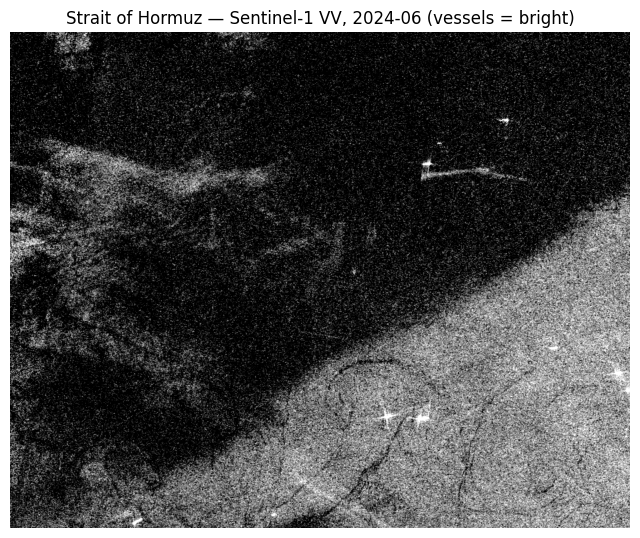

In [3]:
if paths:
    vv = np.asarray(Dataset.read_file(str(paths[0])).read_array(), dtype='float32')
    vv = vv if vv.ndim == 2 else vv[0]
    lo, hi = np.nanpercentile(vv, 40), np.nanpercentile(vv, 99.8)
    plt.figure(figsize=(8, 7))
    plt.imshow(np.clip((vv - lo) / (hi - lo), 0, 1), cmap='gray')
    plt.title('Strait of Hormuz — Sentinel-1 VV, 2024-06 (vessels = bright)')
    plt.axis('off'); plt.show()
else:
    print('no scene written — set GEE_SERVICE_ACCOUNT / GEE_SERVICE_KEY and rerun')